# Modelling earthquake damage using machine learning

This notebook contains a benchmark analysis based on the benchmark blog post by DrivenData. 

The original analysis can be found here:
https://drivendata.co/blog/richters-predictor-benchmark/

The data is available here:
https://www.drivendata.org/competitions/57/nepal-earthquake/

Start by importing libraries needed to import and explore the dataset.

In [21]:
%matplotlib inline

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

Define paths to the data and submission folders.

In [22]:
# REPLACE WITH YOUR OWN PATHS
DATA_DIR = "c:\\Users\\md82\\OneDrive - Anglia Ruskin University\\Documents\\Python_code\\edu-repo\\ML_Applications\\NepalEarthquake\\data\\raw"
SUB_DIR = "c:\\Users\\md82\\OneDrive - Anglia Ruskin University\\Documents\\Python_code\\edu-repo\\ML_Applications\\NepalEarthquake\\submissions"

Load training features and training labels, using the building_id feature as the index column.

In [23]:
train_values = pd.read_csv(DATA_DIR + '\\train_values.csv', index_col='building_id')
train_labels = pd.read_csv(DATA_DIR + '\\train_labels.csv', index_col='building_id')

Start by checking data types.

In [24]:
train_values.dtypes

geo_level_1_id                             int64
geo_level_2_id                             int64
geo_level_3_id                             int64
count_floors_pre_eq                        int64
age                                        int64
area_percentage                            int64
height_percentage                          int64
land_surface_condition                    object
foundation_type                           object
roof_type                                 object
ground_floor_type                         object
other_floor_type                          object
position                                  object
plan_configuration                        object
has_superstructure_adobe_mud               int64
has_superstructure_mud_mortar_stone        int64
has_superstructure_stone_flag              int64
has_superstructure_cement_mortar_stone     int64
has_superstructure_mud_mortar_brick        int64
has_superstructure_cement_mortar_brick     int64
has_superstructure_t

Check the shape of training values:

In [25]:
train_values.shape

(260601, 38)

Check for missing values:

In [26]:
train_values.info()

<class 'pandas.core.frame.DataFrame'>
Index: 260601 entries, 802906 to 747594
Data columns (total 38 columns):
 #   Column                                  Non-Null Count   Dtype 
---  ------                                  --------------   ----- 
 0   geo_level_1_id                          260601 non-null  int64 
 1   geo_level_2_id                          260601 non-null  int64 
 2   geo_level_3_id                          260601 non-null  int64 
 3   count_floors_pre_eq                     260601 non-null  int64 
 4   age                                     260601 non-null  int64 
 5   area_percentage                         260601 non-null  int64 
 6   height_percentage                       260601 non-null  int64 
 7   land_surface_condition                  260601 non-null  object
 8   foundation_type                         260601 non-null  object
 9   roof_type                               260601 non-null  object
 10  ground_floor_type                       260601 non-null 

Check the first rows of the dataset:

In [27]:
train_values.head()

,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
building_id,,,,,,,,,,,,,,,,,,,,,
802906,6,487,12198,2,30,6,5,t,r,n,...,0,0,0,0,0,0,0,0,0,0
28830,8,900,2812,2,10,8,7,o,r,n,...,0,0,0,0,0,0,0,0,0,0
94947,21,363,8973,2,10,5,5,t,r,n,...,0,0,0,0,0,0,0,0,0,0
590882,22,418,10694,2,10,6,5,t,r,n,...,0,0,0,0,0,0,0,0,0,0
201944,11,131,1488,3,30,8,9,t,r,n,...,0,0,0,0,0,0,0,0,0,0


Plot distribution of labels (data imbalance):

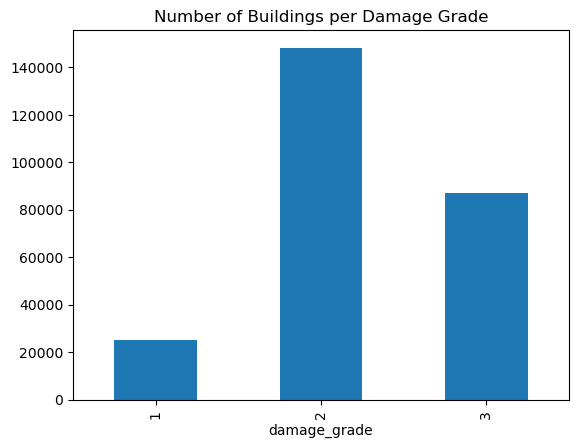

In [28]:
train_labels.damage_grade.value_counts().sort_index().plot(kind='bar', 
                                                           title="Number of Buildings per Damage Grade")
plt.show()

Explore pair-plot of some of the numeric features:

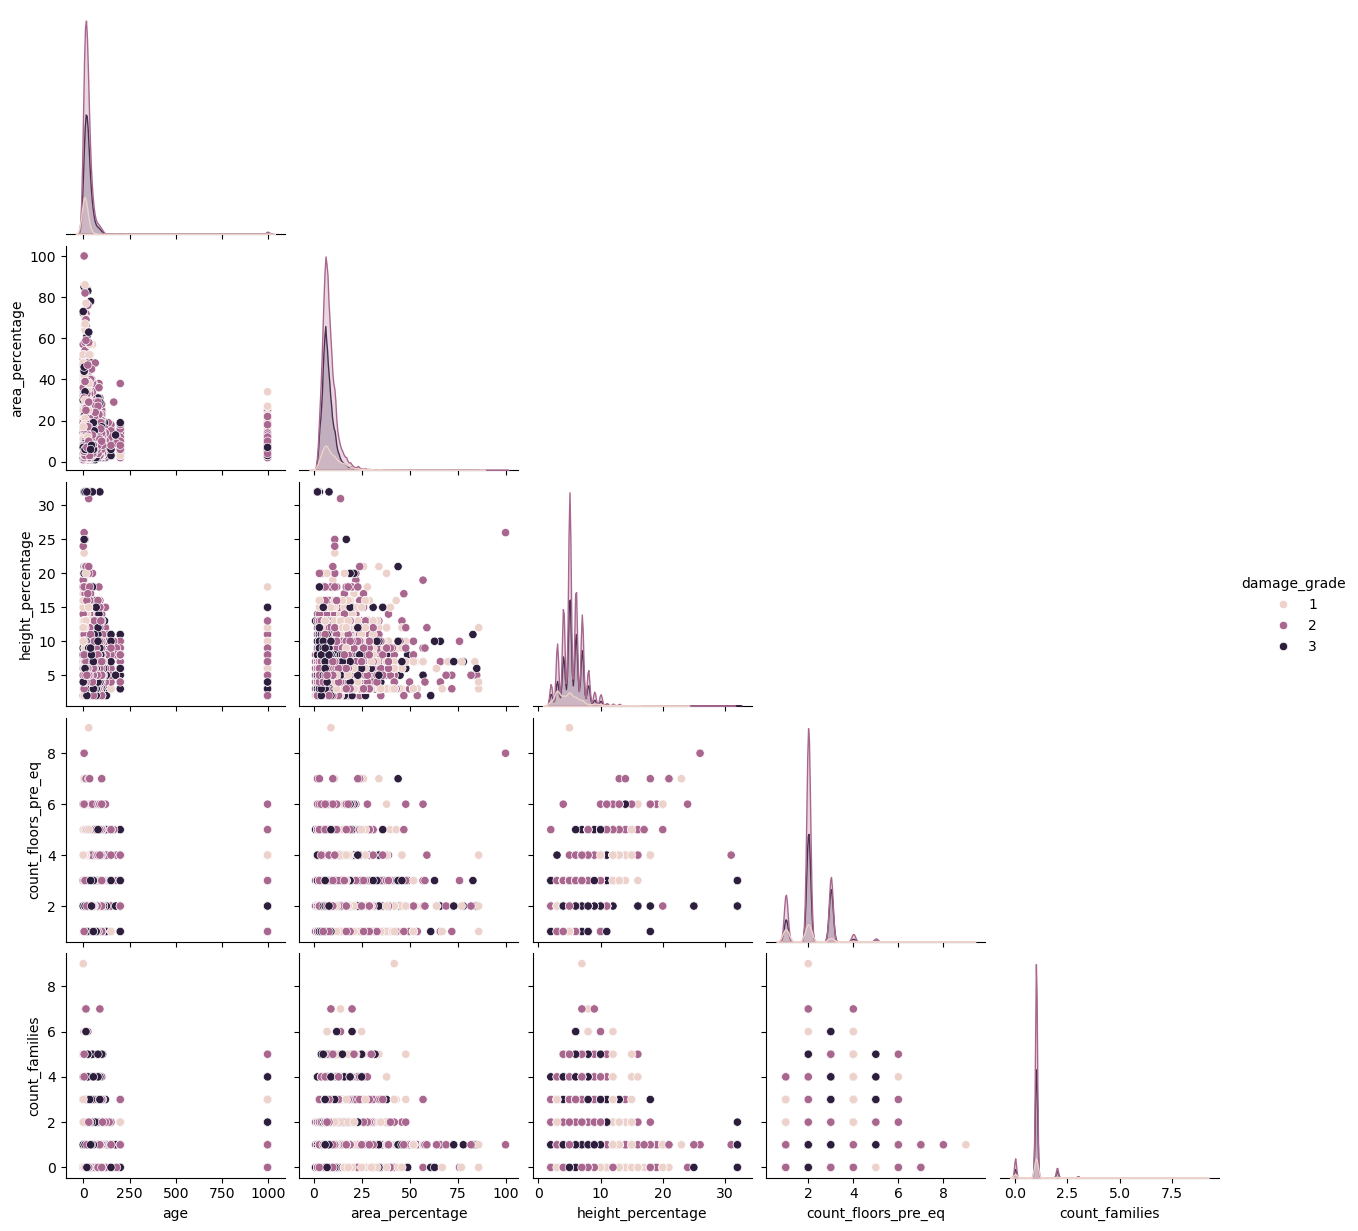

In [31]:
plot_features = ['age',
                'area_percentage', 
                'height_percentage',
                'count_floors_pre_eq',
                'count_families']

data_to_plot = train_values[plot_features]
data_to_plot = data_to_plot.join(train_labels)

df_sample = data_to_plot.sample(frac=0.3, random_state=42)  # 30%
sns.pairplot(df_sample, hue='damage_grade', corner=True)
plt.show()


## Benchmark classification model

Start by importing packages and functionality.

In [32]:
# for preprocessing the data
from sklearn.preprocessing import StandardScaler

# the model
from sklearn.linear_model import LogisticRegression

# for combining the preprocess with model training
from sklearn.pipeline import Pipeline

# for optimizing the hyperparameters of the pipeline
from sklearn.model_selection import train_test_split

# evaluation metrics (f1-score and confusion matrix)
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Select some numerical features for training the benchmark model:

In [33]:
num_features = ['geo_level_1_id',
                'geo_level_2_id',
                'geo_level_3_id',
                'age',
                'area_percentage', 
                'height_percentage',
                'count_floors_pre_eq',
                'count_families']
features = num_features

train_values_num = train_values[features]

# create labels variable
labels = train_labels.damage_grade.to_numpy()

Create processing pipeline:

In [35]:
pipe = Pipeline([("scalar", StandardScaler()),
                ("classifier", LogisticRegression(random_state=0))])

Partition data into train and validation datasets (stratify classes according to labels distribution):

In [36]:
X_train, X_val, y_train, y_val = train_test_split(train_values_num, labels, 
                                                  random_state=42, stratify=labels, test_size=0.2)

In [37]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('scalar', StandardScaler()),
                ('classifier', LogisticRegression(random_state=0))])

Calculate F-score on the training and validation data:

In [38]:
# Training data F1-score
in_sample_preds = pipe.predict(X_train)
f1_score(y_train, in_sample_preds, average='micro')

0.5667977743668458

In [39]:
# Validation data F1-score
out_sample_preds = pipe.predict(X_val)
f1_score(y_val, out_sample_preds, average='micro')

0.5663552119107461

Plot confusion matrix:

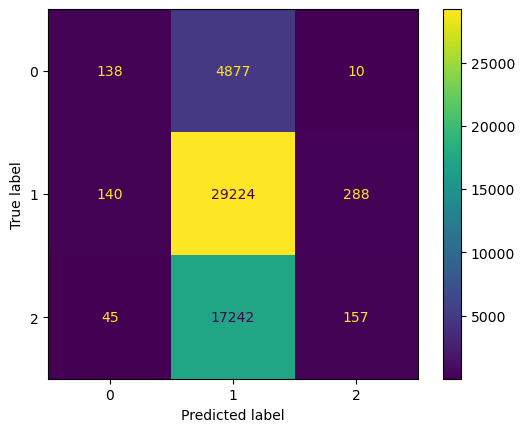

In [40]:
cm = confusion_matrix(y_val, out_sample_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

## Prepare and save submission

Some boilerplate code for running the model on the test dataset and saving the predictions for submission to the DrivenData competition:

In [ ]:
# Uncomment and run the following cells to create your submission file
#test_values = pd.read_csv(DATA_DIR + '\\test_values.csv', index_col='building_id')

#test_values_subset = test_values[features]
#predictions = pipe.predict(test_values_subset)

#submission_format = pd.read_csv(SUB_DIR + '\\submission_format.csv', index_col='building_id')

#my_submission = pd.DataFrame(data=predictions,
#                             columns=submission_format.columns,
#                             index=submission_format.index)

#my_submission.head()
#
#my_submission.to_csv(SUB_DIR + '\\submission.csv')